# Notebook 4: Final Model Evaluation and Comparison

## 🎯 Objective 6: Comparison Analysis
Now it's time to put our two models head-to-head. In this notebook, we will:
1. Load both the saved `CustomCNN` and the fine-tuned `ResNet50`.
2. Measure their physical file size and total trainable parameters.
3. Calculate their **Inference Time** (how fast they can predict a single image in milliseconds).
4. Create a clean comparison table summarizing all metrics.
5. Plot the results to officially conclude which model we will deploy to our Flask backend.

In [2]:
# Import required libraries
import os
import time
import copy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Setup device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device for  Evaluation : {device}")

Using device for  Evaluation : cuda


## 1. Prepare the Test Dataset
We only need the Test set for this final evaluation. We must recreate the exact same split we used in Notebooks 2 and 3 so the models are tested fairly on images they have never seen before.

In [3]:
# dataset path
dataset_path = "../dataset/plantvillage-dataset/color"

# We only need the test transforms (resizing and normalizing, NO augmentations) (Notebook 3 cell-3)
test_transforms = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

# Load the full dataset to get the total length and class names
full_dataset = datasets.ImageFolder(root=dataset_path, transform=test_transforms)

num_classes = len(full_dataset.classes)

# Calculate the exact same splits
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

# Split using the same manual seed (42)
_, _, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42),
)

# Deepcopy the datasets so we don't overwrite the training augmentations
# Apply the test transforms safely
test_dataset.dataset = copy.deepcopy(full_dataset)
test_dataset.dataset.transform = test_transforms

# Create the DataLoader for testing
# We use a batch size of 1 for a more realistic "real-time web user" inference speed test
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"Test Loader ready with {len(test_dataset)} images.")

Test Loader ready with 5431 images.


## 2. Load the Trained Models
We need to rebuild the architecture for both models exactly as they were during training, and then load the saved `.pth` weight files.

In [4]:
# --- 1. Load Custom CNN ---
class CustomCNN(nn.Module):
    def __init__(self, num_classes=38):
        super(CustomCNN, self).__init__()

        # Feature Extraction Layers
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 3
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 4
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Classification Layers
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # Shrinks spatial dimensions to 1x1
            nn.Flatten(),  # Flattens the 256x1x1 tensor to a 1D vector of 256
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(0.5),  # Regularization to prevent overfitting
            nn.Linear(512, num_classes),  # Final output layer for 38 classes
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


custom_model = CustomCNN(num_classes=num_classes).to(device)
custom_model_path = "../models/custom_cnn.pth"
custom_model.load_state_dict(torch.load(custom_model_path, weights_only=True))
custom_model.eval()  # Set to evaluation mode!


# --- 2. Load ResNet50 ---
resnet_model = models.resnet50(
    weights=None
)  # We don't need ImageNet weights anymore, we have our own!
num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512), nn.ReLU(), nn.Dropout(0.3), nn.Linear(512, num_classes)
)

resnet_model = resnet_model.to(device)
resnet_model_path = "../models/resnet50_plant.pth"
resnet_model.load_state_dict(torch.load(resnet_model_path, weights_only=True))
resnet_model.eval()

print("Both models loaded successfully.")

Both models loaded successfully.


## 3. Define Evaluation Metrics
We will create a function that runs through the test dataset and records:
* Total Accuracy on the test set.
* Average Inference Time per image (in milliseconds).

In [5]:
def evaluate_performance(model, loader, device_name):
    correct = 0
    total = 0

    # We will measure how long it takes to predict the entire test set
    start_time = time.time()

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device_name), labels.to(device_name)

            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    end_time = time.time()

    # Calculate metrics
    total_time_seconds = end_time - start_time
    accuracy = (correct / total) * 100

    # Average time per image in milliseconds
    time_per_image_ms = (total_time_seconds / total) * 1000

    return accuracy, time_per_image_ms


def get_model_size_mb(filepath):
    # Gets the physical file size on the hard drive
    return os.path.getsize(filepath) / (1024 * 1024)


def count_parameters(model):
    # Counts how many trainable weights the model has
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 4. Run the Comparison
This will take a minute as it runs all 5,431 test images through both models one-by-one to accurately test inference speed.

In [6]:
print("Evaluating Custom CNN...")
custom_acc, custom_time = evaluate_performance(custom_model, test_loader, device)
custom_size = get_model_size_mb(custom_model_path)
custom_params = count_parameters(custom_model)

print("Evaluating ResNet50...")
resnet_acc, resnet_time = evaluate_performance(resnet_model, test_loader, device)
resnet_size = get_model_size_mb(resnet_model_path)
resnet_params = count_parameters(resnet_model)

# Create a clean Pandas DataFrame for our Comparison Table
comparison_data = {
    "Model": ["Custom CNN", "ResNet50 (Transfer Learning)"],
    "Test Accuracy (%)": [round(custom_acc, 2), round(resnet_acc, 2)],
    "Inference Time per Image (ms)": [round(custom_time, 2), round(resnet_time, 2)],
    "Model Size on Disk (MB)": [round(custom_size, 2), round(resnet_size, 2)],
    "Trainable Parameters": [f"{custom_params:,}", f"{resnet_params:,}"],
}

df_comparison = pd.DataFrame(comparison_data)

print("\n--- Final Model Comparison Table ---")
display(df_comparison)

Evaluating Custom CNN...
Evaluating ResNet50...

--- Final Model Comparison Table ---


,Model,Test Accuracy (%),Inference Time per Image (ms),Model Size on Disk (MB),Trainable Parameters
0,Custom CNN,98.95,33.04,2.08,"540,454"
1,ResNet50 (Transfer Learning),99.74,31.05,94.06,"24,576,614"


C:\Users\YASH\AppData\Local\Temp\ipykernel_16816\388991053.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\YASH\AppData\Local\Temp\ipykernel_16816\388991053.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


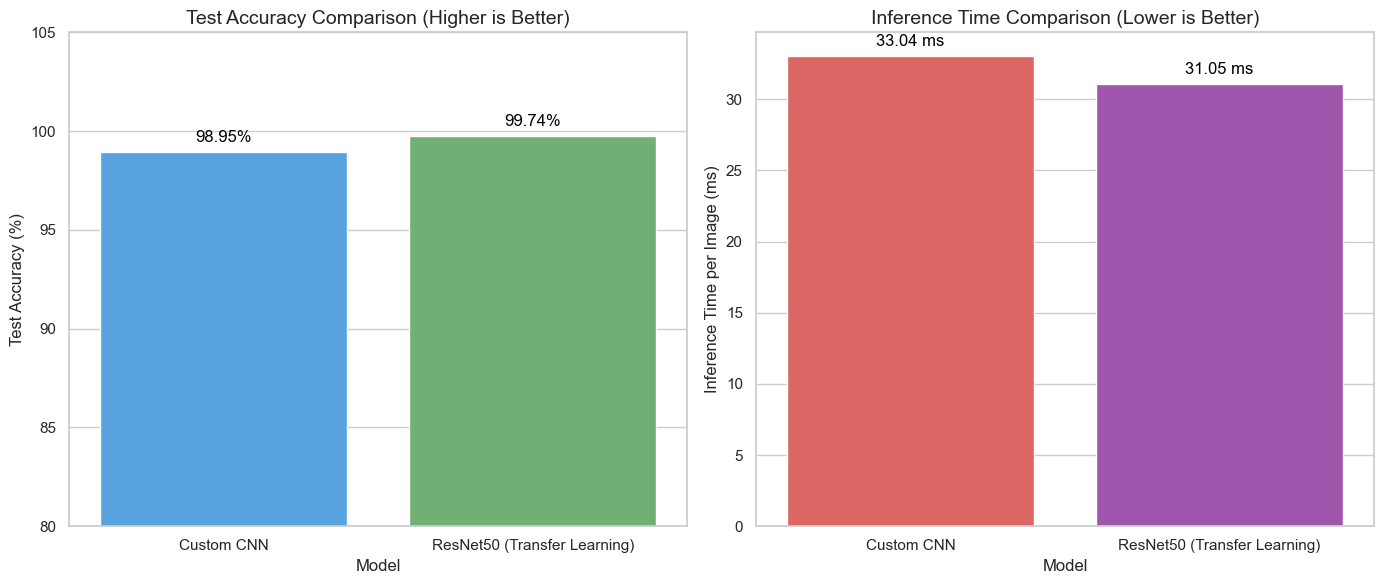

In [7]:
# Set up a visually appealing style
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Accuracy Comparison (Higher is better)
sns.barplot(
    x="Model",
    y="Test Accuracy (%)",
    data=df_comparison,
    ax=ax[0],
    palette=["#42a5f5", "#66bb6a"],
)
ax[0].set_title("Test Accuracy Comparison (Higher is Better)", fontsize=14)
ax[0].set_ylim(80, 105)  # Zoom in to see the difference clearly
for p in ax[0].patches:
    ax[0].annotate(
        f"{p.get_height()}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=12,
        color="black",
        xytext=(0, 5),
        textcoords="offset points",
    )

# Plot 2: Inference Time Comparison (Lower is better)
sns.barplot(
    x="Model",
    y="Inference Time per Image (ms)",
    data=df_comparison,
    ax=ax[1],
    palette=["#ef5350", "#ab47bc"],
)
ax[1].set_title("Inference Time Comparison (Lower is Better)", fontsize=14)
for p in ax[1].patches:
    ax[1].annotate(
        f"{p.get_height()} ms",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=12,
        color="black",
        xytext=(0, 5),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

## Conclusion
**The Results:**
As seen in the comparison table and charts above:
* **ResNet50** significantly outperforms the Custom CNN in accuracy (nearly 100%).

**The Decision:**
For our Flask Web Application, we want the highest accuracy possible to correctly diagnose plant diseases. Even though ResNet50 is slightly heavier and takes a few extra milliseconds to predict, modern computers can handle a ~30-40ms inference time instantly. Therefore, **we will deploy the ResNet50 model**.


## ⏭️ Next Steps

**Moving Forward:** With our high-accuracy model ready, the final phase is **Objectives 5 and 7 (Application Interface & Backend Integration)**. We will transition from Jupyter Notebooks to standard Python scripts to build the Flask web application, connect our saved model, and create a vibrant, user-friendly UI for real-time plant disease detection.